In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris # To load the Iris dataset easily

# --- Task 1: Load and Explore the Dataset ---

print("--- Task 1: Load and Explore ---")

try:
    iris = load_iris()
    # Create a pandas DataFrame
    # iris.data contains the features, iris.feature_names the column names
    df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
    # Add the target variable (species) as a new column
    # iris.target contains numeric codes (0, 1, 2)
    # iris.target_names contains the corresponding names ('setosa', 'versicolor', 'virginica')
    df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
    print("Iris dataset loaded successfully from sklearn.")
except ImportError:
    print("Error: sklearn is not installed. Please install it to load the Iris dataset.")
    exit()

--- Task 1: Load and Explore ---
Iris dataset loaded successfully from sklearn.


In [2]:
# Display the first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Explore the structure: data types and non-null counts
print("\nDataset structure (info):")
df.info()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Clean the dataset (Example: Filling missing values - Iris usually has none)
if df.isnull().sum().sum() > 0:
    print("\nCleaning missing values...")
    # Drop rows with any missing values
    df_cleaned = df.dropna()
    print(f"Shape before dropping NaNs: {df.shape}")
    print(f"Shape after dropping NaNs: {df_cleaned.shape}")
    print("\nMissing values after cleaning:")
    print(df.isnull().sum())
else:
    print("\nNo missing values found in the dataset. No cleaning needed.")


First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Dataset structure (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64

In [3]:
# --- Task 2: Basic Data Analysis ---

print("--- Task 2: Basic Data Analysis ---")

# Compute basic statistics for numerical columns
print("\nBasic statistics for numerical columns:")
# Use .T to transpose for potentially better readability
print(df.describe().T)

# Perform groupings on the 'species' column and compute the mean for numerical columns
print("\nMean values of numerical columns grouped by species:")
grouped_means = df.groupby('species').mean() # Default is to aggregate numeric columns
print(grouped_means)

# Identify patterns or interesting findings
print("\nFindings/Observations from Basic Analysis:")
print("1. Statistical Summary: The .describe() output shows the central tendency (mean, median), dispersion (std dev), and range (min, max) for each measurement. We can see differences in the scales (e.g., sepal length is generally larger than petal width).")
print("2. Grouped Analysis: The grouped means clearly show distinct differences between the species:")
print("   - 'setosa' generally has the smallest petal length and width but relatively wider sepals compared to its sepal length.")
print("   - 'virginica' generally has the largest petal length, petal width, and sepal length.")
print("   - 'versicolor' measurements tend to fall between 'setosa' and 'virginica'.")
print("3. These distinct measurement patterns suggest that these features are useful for distinguishing between the Iris species.")

--- Task 2: Basic Data Analysis ---

Basic statistics for numerical columns:
                   count      mean       std  min  25%   50%  75%  max
sepal length (cm)  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9
sepal width (cm)   150.0  3.057333  0.435866  2.0  2.8  3.00  3.3  4.4
petal length (cm)  150.0  3.758000  1.765298  1.0  1.6  4.35  5.1  6.9
petal width (cm)   150.0  1.199333  0.762238  0.1  0.3  1.30  1.8  2.5

Mean values of numerical columns grouped by species:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  
species                       
setosa                 0.246  
versicolor             1.326  
virginica              2.026  

Finding

--- Task 3: Data Visualization ---

Generating Line Chart...


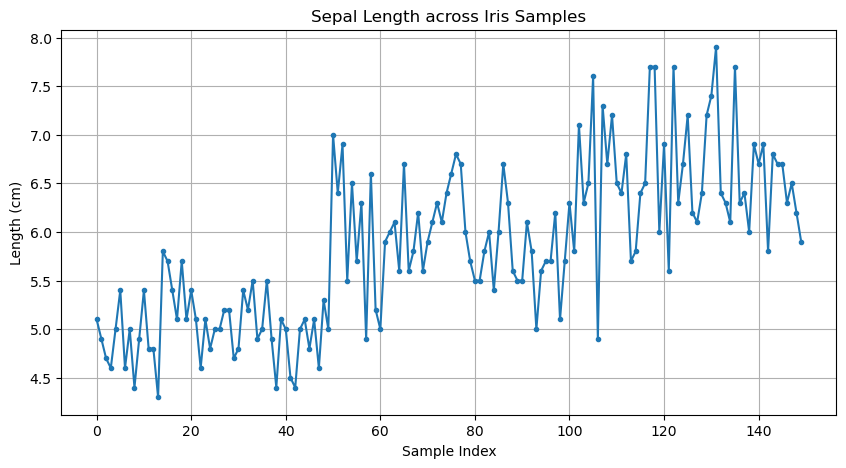

In [5]:
# --- Task 3: Data Visualization ---

print("--- Task 3: Data Visualization ---")

# 1. Line Chart (Example: Sepal Length across samples)
plt.figure(figsize=(10, 5)) # Set figure size
plt.plot(df.index, df['sepal length (cm)'], marker='.', linestyle='-', label='Sepal Length (cm)')
plt.title('Sepal Length across Iris Samples')
plt.xlabel('Sample Index')
plt.ylabel('Length (cm)')
plt.grid(True)
print("\nGenerating Line Chart...")
plt.show() # Display the plot


Generating Bar Chart...


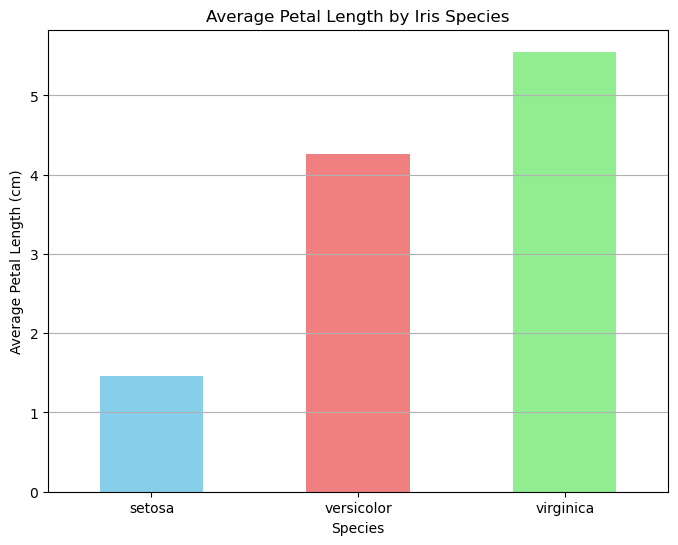

In [6]:
# 2. Bar Chart (Comparison of mean Petal Length across species)
# Use the grouped data calculated earlier
plt.figure(figsize=(8, 6))
grouped_means['petal length (cm)'].plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Average Petal Length by Iris Species')
plt.xlabel('Species')
plt.ylabel('Average Petal Length (cm)')
plt.xticks(rotation=0) # Keep species names horizontal
plt.grid(axis='y') # Grid lines on the y-axis only
print("\nGenerating Bar Chart...")
plt.show()


Generating Histogram...


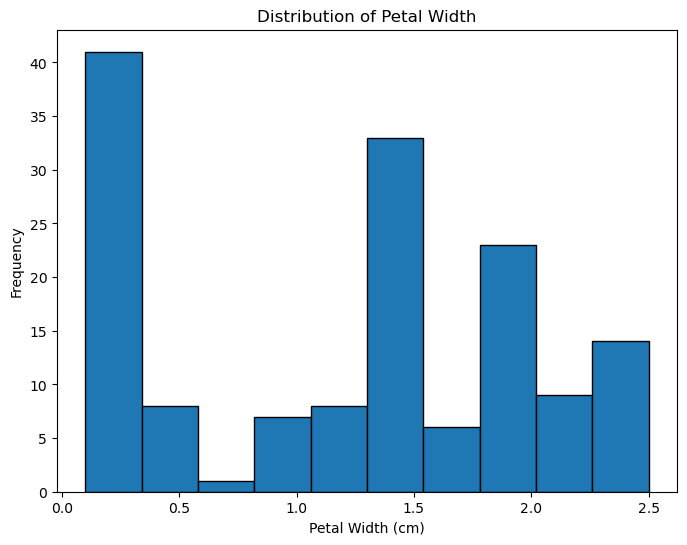

In [7]:
# 3. Histogram (Distribution of Petal Width)
plt.figure(figsize=(8, 6))
plt.hist(df['petal width (cm)'], bins=10, edgecolor='black')
plt.title('Distribution of Petal Width')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
print("\nGenerating Histogram...")
plt.show()


Generating Scatter Plot...


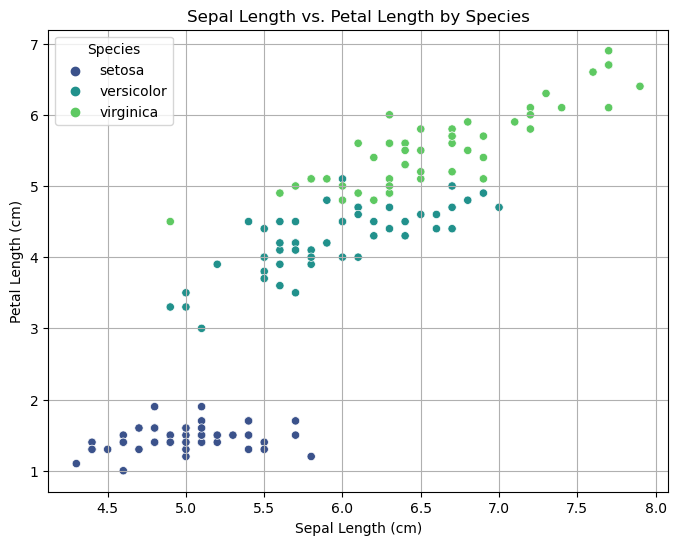

In [12]:
# 4. Scatter Plot (Relationship between Sepal Length and Petal Length)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='sepal length (cm)', y='petal length (cm)', hue='species', palette='viridis')
plt.title('Sepal Length vs. Petal Length by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend(title='Species')
plt.grid(True)
print("\nGenerating Scatter Plot...")
plt.show()

In [ ]:
print("\n--- Analysis Complete ---")
print("Observations from Visualizations:")
print("- Line Chart: Shows the variation of sepal length across individual samples but lacks a time dimension in this dataset.")
print("- Bar Chart: Visually confirms the finding from Task 2 that average petal lengths differ significantly between species.")
print("- Histogram: Shows the distribution of petal widths. It appears multi-modal, likely reflecting the different species groups (e.g., 'setosa' has very small petal widths).")
print("- Scatter Plot: Clearly visualizes the relationship between sepal and petal length. It shows a positive correlation (longer sepals tend to correspond with longer petals) and demonstrates how the different species cluster in this 2D feature space. 'setosa' is distinctly separated from the other two species.")

print("\n--- End of Analysis ---")